## Проект спринта 12. Прогнозирование CTR в рекламных аукционах.

## Цель и задачи.
**Цель:** Увеличение прибыли платформы онлайн-рекламы при помощи улучшения механизма прогнозирования вероятности перехода пользователей по рекламным ссылкам.

### Задачи:
1. Загрузка данных и знакомство с их содержимым.
2. Исследовательский анализ данных.
3. Отбор признаков для задачи машинного обучения.
3. Предобработка данных для машинного обучения.
4. Разработка механизма предсказания оттока клиентов.
    - Обучение и оценка базовых моделей классификации.
    - Подбор гиперпараметров моделей.
    - Калибровка прогнозируемых моделями вероятностей.
    - Финальное обучение моделей и подготовка артефактов.
5. Формулировка выводов, содержащих оценку и анализ результатов обучения моделей.

### Постановка задачи в терминах машинного обучения
- Необходимо решить задачу машинного обучения для предсказания вероятности клика (CTR) на рекламном объявлении на основе предоставленного датасета с признаками и значениями целевой переменной.
- Тип задачи машинного обучения: бинарная классификация.
- Целевая переменная - вероятность клика на рекламной объявлении (CTR).
- Модели машинного обучения - логистическая регрессия и метод опорных векторов (SVM) с линейным ядром.
- Необходимо откалибровать вероятности, возвращаемые моделями, т.е. обеспечить их соответствие реальной частоте классов.
- Основные метрики - PR-AUC, Log Loss, Brier score. Вспомогательные метрики - Precision, Recall, F1. Метрики для калибровки - ECE, MCE. 
- Необходимо обеспечить воспроизводимость результатов при помощи указания фиксированного значения `random_state`.
- Для тестовой выборки необходимо выделить 20% измерений из датасета.
- Решение должно быть сохранено в виде готового к промышленной эксплуатации пайплайна.

### Данные

Для анализа поступили данные в формате CSV-файла, который доступен по ссылке [ds_s16_ad_click_dataset](https://code.s3.yandex.net/data-scientist/ds_s16_ad_click_dataset.csv).

- **Период агрегации.** Данные содержат информацию о показе рекламных баннеров и действиях пользователей за фиксированный временной промежуток.
- **Формат данных.** Данные представлены в виде готовой аналитической витрины. Это означает, что для каждого показа рекламного баннера уже рассчитаны и собраны в одну строку все необходимые для моделирования признаки.
- **Структура.** Каждая строка соответствует одному уникальному событию показа рекламы. Все признаки предварительно обработаны и представлены в виде числовых и категориальных значений.
- **Данные анонимизированы.** Датасет прошёл предварительную обработку для обеспечения анонимности и сохранности данных. Например, в признаке `site_category` содержатся такие категории, как `50e219e0` и `3e814130`.

#### **Признаки в датасете**

**Идентификаторы и временные метки:**

- `id` — уникальный идентификатор записи о показе баннера;
- `hour` — час, в который был показан баннер, в формате `YYMMDDHH`.

**Характеристики рекламной площадки ( `Site` ):**

- `site_id` — идентификатор веб-сайта, на котором был показан баннер;
- `site_domain` — домен веб-сайта;
- `site_category` — тематическая категория веб-сайта.

**Характеристики рекламируемого приложения ( `App` ):**

- `app_id` — идентификатор рекламируемого мобильного приложения;
- `app_domain` — домен рекламируемого приложения;
- `app_category` — категория рекламируемого приложения.

**Характеристики устройства и соединения пользователя:**

- `device_id` — идентификатор браузера или устройства;
- `device_ip` — IP-адрес устройства;
- `device_model` — модель устройства;
- `device_type` — тип устройства пользователя: например, смартфон, планшет, ПК;
- `device_conn_type` — тип сетевого соединения устройства: например, Wi-Fi, 3G, 4G.

**Характеристики рекламного баннера и аукциона:**

- `banner_pos` — позиция баннера на веб-странице;
- `C1` — анонимизированный признак, характеризующий контекст показа;
- `C14` — `C21` — группа анонимизированных признаков, описывающих параметры баннера, пользователя или аукциона.

**Машинно-сгенерированные признаки (ML Features):**

- `ml_feature_1`, `ml_feature_3` — `ml_feature_6`, `ml_feature_8` — `ml_feature_10` — числовые признаки, полученные в результате предварительной обработки и генерации новых признаков;
- `ml_feature_2`, `ml_feature_7` — категориальные признаки, полученные в результате предварительной обработки и генерации новых признаков.

**Целевая переменная:**

- `click` — бинарный признак, указывающий, был ли совершён клик по баннеру. `1` — клик был, `0` — клика не было.

# Структура проекта

## 1. Подготовка среды и загрузка данных

#### 1.1 Подготовка библиотек

- Установка необходимых пакетов:

In [1]:
# %pip install -q numpy==1.23
# %pip install -q --upgrade scikit-learn
# %pip install -q --upgrade seaborn
# %pip install -q --upgrade jinja2
# %pip install -q phik

# Сохраним версии библиотек в requirements.txt
%pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


- Импортируем необходимые пакеты:

In [41]:
import math

import pandas as pd
import numpy as np
import phik

# Библиотеки машинного обучения
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, TargetEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.frozen import FrozenEstimator
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, \
    average_precision_score, log_loss, recall_score, precision_score, brier_score_loss
from sklearn.model_selection import cross_validate, StratifiedKFold, GridSearchCV
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif, RFE
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

# Библиотеки для построения графиков
import seaborn as sns
import matplotlib.pyplot as plt

# Сериализация пайплайна
import joblib

# Для форматирования в HTML
from IPython.display import display, HTML, Markdown

#### 1.2 Фиксация константы для воспроизводимости
- Зафиксируем значение `random_state` для воспроизводимости результатов:

In [3]:
RANDOM_SEED=42

#### 1.3 Загрузка данных
- Загрузим данные из датасета и выведем основные сведения о них:

In [4]:
try:
    # Сначала загрузим данныз из локального файла
    df = pd.read_csv("datasets/ds_s16_ad_click_dataset.csv")
except FileNotFoundError:
    # Если файла нет, загружаем по сети
    df = pd.read_csv("https://code.s3.yandex.net/data-scientist/ds_s16_ad_click_dataset.csv")

display(df.info())
display(df.head(10))

initial_count = len(df)

# Посчитаем количество явных дубликатов
dup_columns = df.columns.to_list()
dup_columns.remove('id')
dup_columns.remove('device_id')
dup_count = df[dup_columns].duplicated().sum()
print(f"Количество дубликатов: {dup_count} ({dup_count / initial_count * 100: .2f}%)")
print("\nКоличество уникальных значений по столбцам:")
display(pd.DataFrame(df.nunique()).sort_values(by=0, ascending=False).style.background_gradient(cmap='coolwarm'))

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int64  
 2   hour              50000 non-null  int64  
 3   C1                50000 non-null  int64  
 4   banner_pos        50000 non-null  int64  
 5   site_id           50000 non-null  str    
 6   site_domain       50000 non-null  str    
 7   site_category     50000 non-null  str    
 8   app_id            50000 non-null  str    
 9   app_domain        50000 non-null  str    
 10  app_category      50000 non-null  str    
 11  device_id         50000 non-null  str    
 12  device_ip         50000 non-null  str    
 13  device_model      50000 non-null  str    
 14  device_type       50000 non-null  int64  
 15  device_conn_type  50000 non-null  int64  
 16  C14               50000 non-null  int64  
 17  C15 

None

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,1.005263e+19,1,14102100,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,...,-0.996823,A,0.666588,0,0.817292,0.993275,Z,-0.619959,0.433666,0.274038
1,1.010597e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,-0.391309,C,5.146789,1,-0.883865,-0.825722,X,0.576526,-0.318558,-0.132851
2,1.012048e+19,0,14102100,1005,0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,...,-2.112732,D,7.169348,0,-0.859440,-0.338365,Y,-0.440047,-0.345412,0.340487
3,1.021995e+18,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,...,0.332707,A,-0.290708,1,0.062795,0.062934,Y,0.551982,0.733382,-0.198542
4,1.023455e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1.166623,A,6.319134,1,-0.675276,0.797144,X,0.640827,0.297955,-0.136909
5,1.037910e+19,1,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,-0.386621,D,-2.561220,1,-0.327084,0.997424,Y,-0.718630,0.063355,0.118050
6,1.046962e+19,0,14102100,1005,0,543a539e,c7ca3108,3e814130,ecad2386,7801e8d9,...,-1.029484,B,0.616779,0,-0.088135,-0.484160,Y,0.390766,0.399371,0.278207
7,1.048718e+19,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,fbbccc58,2347f47a,...,-1.412949,A,0.667451,0,0.010914,-0.607470,Y,0.216093,0.746051,0.439438
8,1.056080e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,-1.841339,C,-8.415390,0,-0.774189,-0.957543,Z,-0.230077,0.574167,-0.054031
9,1.081451e+19,1,14102100,1005,1,e59ef3fc,0a4015b2,335d28a8,ecad2386,7801e8d9,...,-1.098406,D,6.310419,0,1.930692,-0.980213,Y,-0.354278,0.372335,0.321687


Количество дубликатов: 0 ( 0.00%)

Количество уникальных значений по столбцам:


,0
id,50000
ml_feature_10,50000
ml_feature_6,50000
ml_feature_5,50000
ml_feature_3,50000
ml_feature_8,50000
ml_feature_1,50000
ml_feature_9,50000
device_ip,41455
device_id,8580


#### Выводы:
- Явные дубликаты и пропуски отсутстсвуют.
- Все признаки, за исключением `ml_feature_1`, `ml_feature_3`, `ml_feature_5`, `ml_feature_6`, `ml_feature_8-10` являются категориальными/дискретными.
- Наибольшее количество категорий - в признаке `device_ip` (41455)

## 2. Исследовательский анализ данных (EDA)

#### 2.1 Базовая информация о датасете
- Количество записей в датасете - 50000. Пропуски и явные дубликаты отсутствуют.
- Датасет содержит 33 признака и одну целевую переменную (`click`).
- Категориальные и дискретные признаки (в количестве 25) имеют типы `str` и `int64`.
- Анонимизированные признаки с типом `str` содержат строковое представление шестнадцатеричной записи 32-разрядных чисел.
- Машинно-сгенерированные признаки `ml_feature_2` и `ml_feature_7` содержат однобуквенные обозначения, признак `ml_feature_4` содержит флаг 0/1.
- Числовые признаки (7 штук) и идентификатор имеют тип `float64`.

- Опишем функции для построения графиков и диаграмм:

In [5]:
# Функция для построения скаттерплота в сетке
def draw_scatterplot_grid(data, 
                     title, 
                     x, 
                     y, 
                     hue,
                     xlabel, 
                     ylabel,
                     ax):
    sns.scatterplot(data=data, 
                    x=x,
                    y=y,
                    hue=hue, 
                    ax=ax)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

# Функция для построения боксплота в сетке
def draw_boxplot_grid(data,
                    field,
                    title, 
                    xlabel, 
                    ylabel, 
                    **kwargs):
    sns.boxplot(data=data,
                x=field,   
                showmeans=True,
                legend=False,
                meanprops={
                    "marker": "o",
                    "markerfacecolor": "white",
                    "markeredgecolor": "black",
                    "markersize": 8
                },
                orient='h',
                **kwargs)
    kwargs['ax'].set_title(title)
    kwargs['ax'].set_xlabel(xlabel)
    kwargs['ax'].set_ylabel(ylabel)

# Функция для построения в сетке
def draw_histogram(data,
                    field,
                    title,
                    xlabel, 
                    ylabel,
                    figsize=(12,6),
                    **kwargs):
    sns.histplot(data=data,
                x=field,
                 **kwargs)

    plt.figure(figsize=figsize)
    plt.title(title)
    # plt.xticks(np.arange(0, 1300, step=50), rotation=90)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

# Функция для построения гистограммы в сетке
def draw_histogram_grid(data,
                        field,
                        title,
                        xlabel, 
                        ylabel,
                        **kwargs):
    sns.histplot(data=data,
                x=field,
                 **kwargs)

    # plt.xticks(np.arange(0, 1300, step=50), rotation=90)
    kwargs['ax'].set_title(title)
    kwargs['ax'].set_xlabel(xlabel)
    kwargs['ax'].set_ylabel(ylabel)

# Функция для построения столбчатой диаграммы в сетке
def draw_barplot_grid(series, 
                 title, 
                 xlabel, 
                 ylabel, 
                 rot, 
                 vertical, 
                 mean,
                 ax):
    series.head(20).plot(
        title=title,
        kind='bar' if vertical else 'barh',
        xlabel=xlabel if vertical else ylabel,
        ylabel=ylabel if vertical else xlabel,
        grid=True,
        rot=rot,
        ax=ax)
    
    if mean != None:
        if vertical:
            ax.axhline(mean, color='red', linestyle='--')
        else:
            ax.axvline(mean, color='red', linestyle='--')    

# Функция для построения тепловой карты
def draw_heatmap(df, title, figsize=(12,12), font_scale=0.8):
    plt.figure(figsize=figsize)
    plt.title(title)
    sns.set_theme(font_scale=font_scale)
    sns.heatmap(data=df, annot=True, fmt='.2f', linewidths=0.5, cmap='viridis')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()    

# Функция для построения гистограммы и боксплота на одной шкале
def draw_double_diag(data, title, x, hue, xlabel, ylabel, stat='count', figsize=(12, 6), bins='auto', kde=True):
    fig, (ax_hist, ax_box) = plt.subplots(
        nrows=2,
        ncols=1,
        sharex=True,
        figsize=figsize,
        gridspec_kw={'height_ratios': [2, 1]}
    )

    sns.boxplot(data=data,
                ax=ax_box,
                x=x, 
                hue=hue, 
                showmeans=True,
                legend=False,
                meanprops={
                    "marker": "o",
                    "markerfacecolor": "white",
                    "markeredgecolor": "black",
                    "markersize": 8
                })

    ax_box.set_xlabel('')  # Убираем подпись оси X, чтобы не дублировалась
    ax_box.set_ylabel('')  # Убираем подпись оси Y
    ax_box.set_yticks([])  # Убираем тики оси Y (они не нужны)

    sns.histplot(data=data,
                ax=ax_hist,
                x=x,
                hue=hue,
                kde=kde,
                bins=bins,
                stat=stat)

    ax_hist.set_xlabel(xlabel)
    ax_hist.set_ylabel(ylabel)

    fig.suptitle(title, fontsize=14)

    plt.tight_layout()
    plt.show()

    # Функция для построения столбчатой диаграммы
def draw_barplot(series, 
                 title, 
                 xlabel, 
                 ylabel, 
                 rot=0, 
                 vertical=True, 
                 mean=None):
    series.head(10).plot(
        title=title,
        kind='bar' if vertical else 'barh',
        figsize=(8, 4) if vertical else (12, 4),
        xlabel=xlabel if vertical else ylabel,
        ylabel=ylabel if vertical else xlabel,
        grid=True,
        rot=rot)
    
    if mean != None:
        if vertical:
            plt.axhline(mean, color='red', linestyle='--')
        else:
            plt.axvline(mean, color='red', linestyle='--')
    plt.show()

- Исследуем распределение целевой переменной и баланс классов:

Количество записей в положительном классе: 8603 (17.21%)
Количество записей в нулевом классе: 41397 (82.79%)


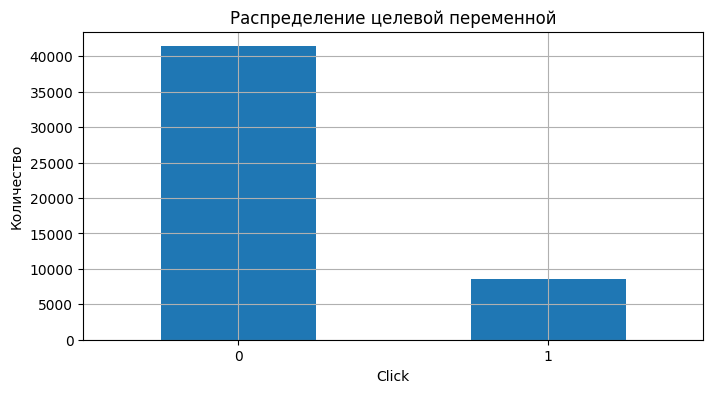

In [6]:
click_positive_count = df['click'].sum()
click_positive_ratio = click_positive_count / len(df)
print(f"Количество записей в положительном классе: {click_positive_count} ({click_positive_ratio * 100:.2f}%)")
print(f"Количество записей в нулевом классе: {len(df) - click_positive_count} ({(1 - click_positive_ratio) * 100:.2f}%)")
draw_barplot(df['click'].value_counts(),
             'Распределение целевой переменной',
             'Click',
             'Количество')

Наблюдается дисбаланс классов целевой переменной. Положительный класс (переход пользователя по ссылке) составляет 17.21% от всех показов рекламы

- Для категориальных признаков с небольшим количеством значений (67 и менее) построим столбчатые диаграммы доли кликов.
- Для категориальных признаков с большим количеством значений построим столбчатые диаграммы сравнения полного количества с количеством кликов.
- В обоих случаях выведем 20 наибольших значений.
- Признак `hours` необходимо разбить на несколько признаков (год, месяц, день, час), чтобы было возможно выявить возможные циклические колебания.

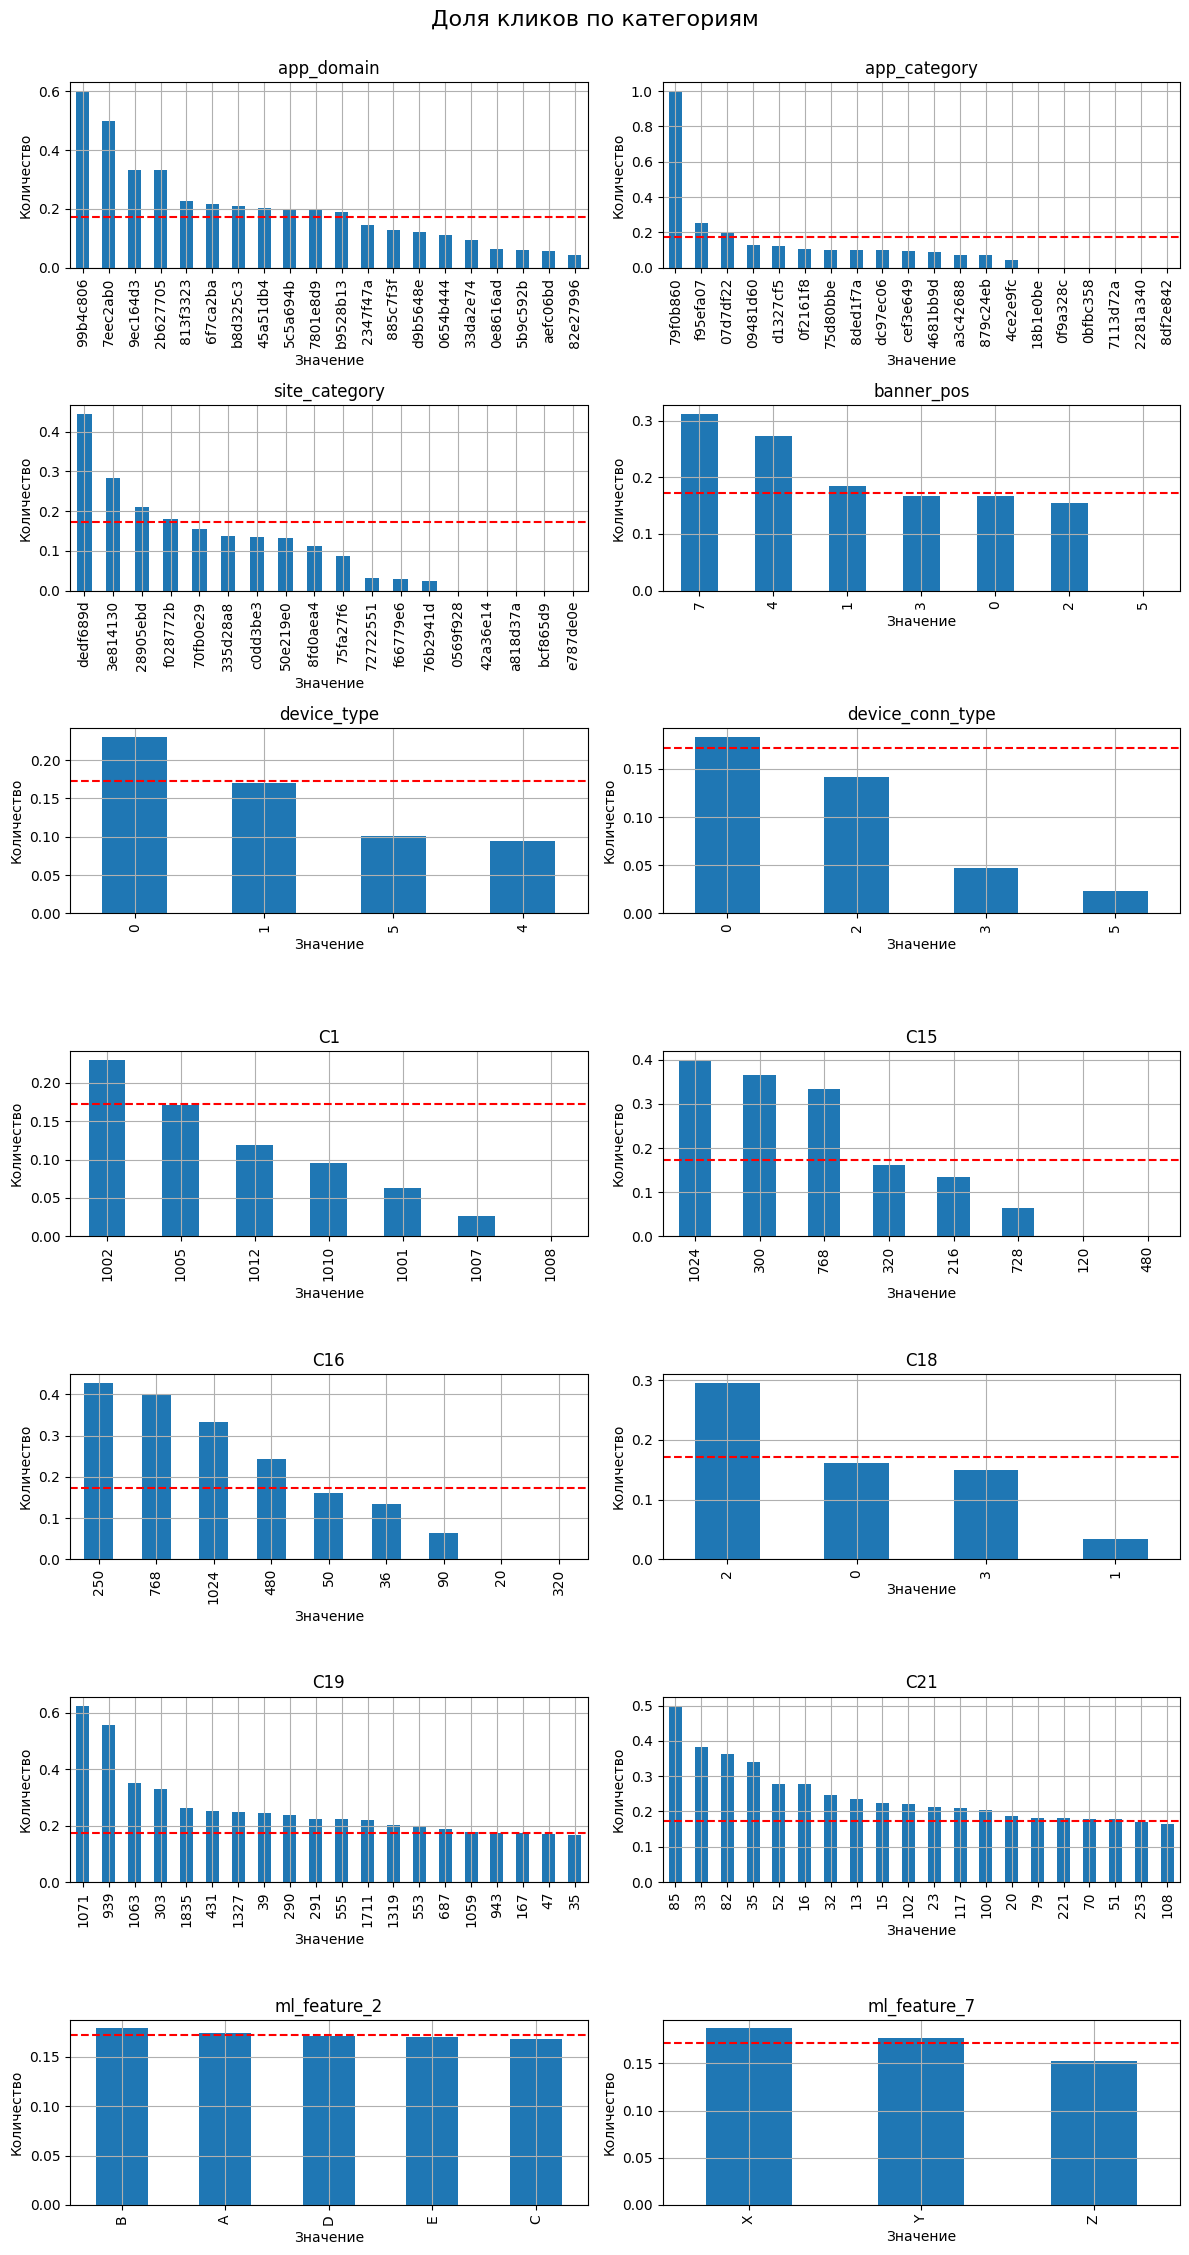

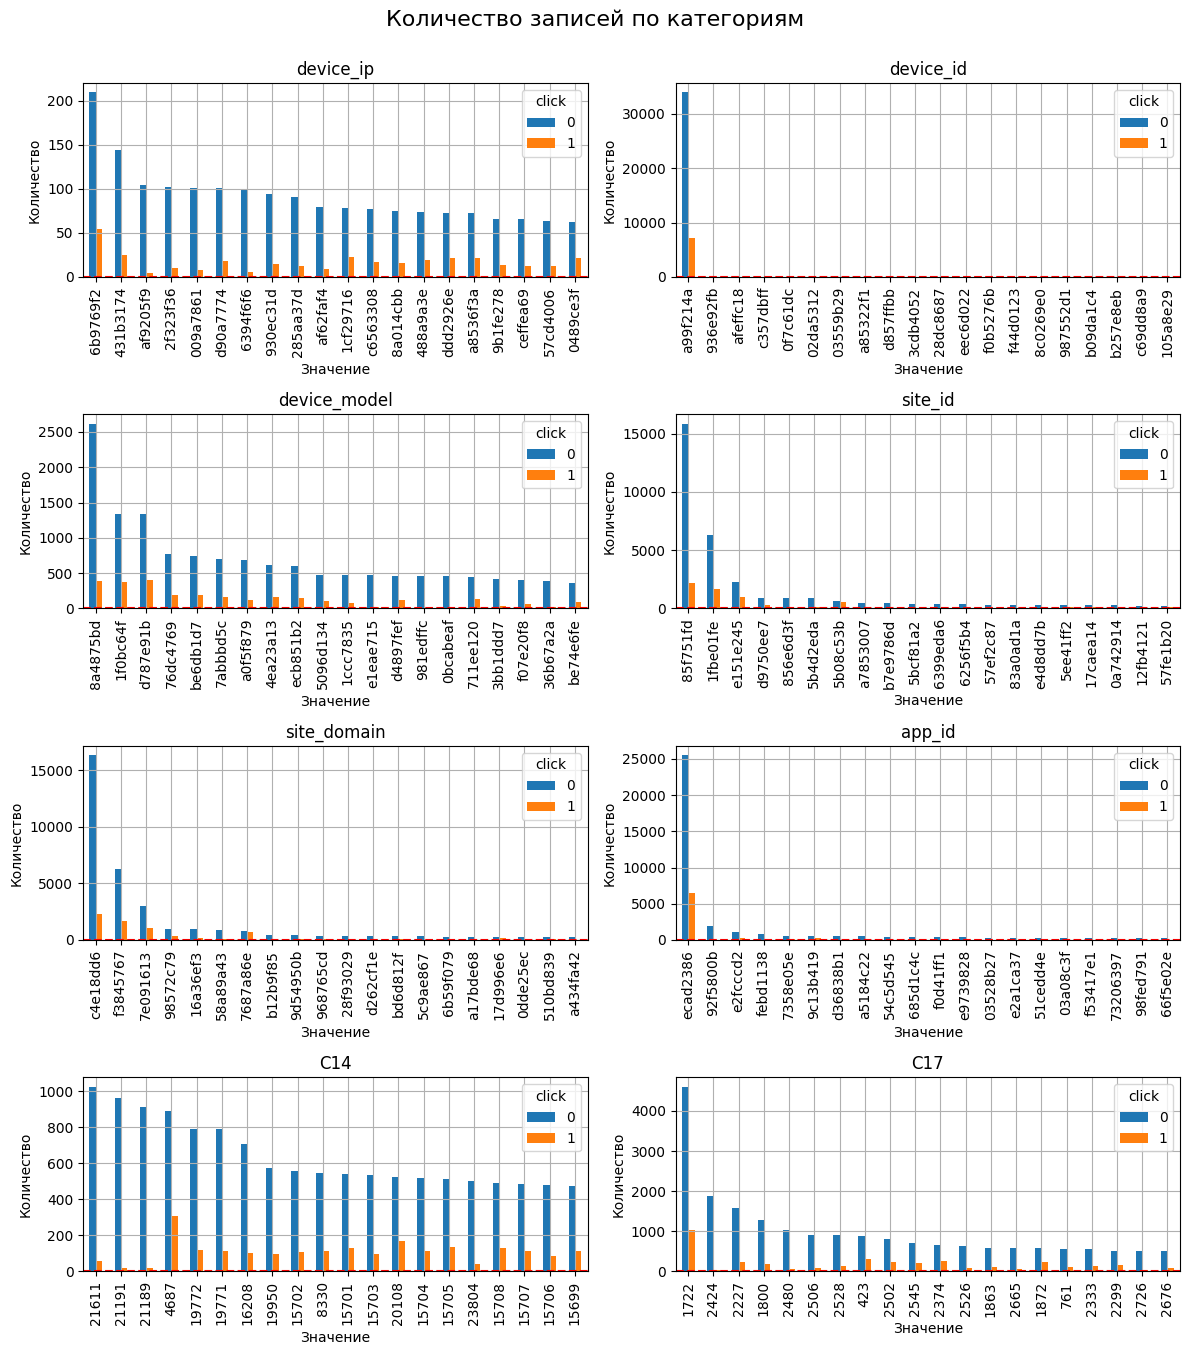

In [7]:
# Числовые признаки
num_features = ['ml_feature_1',
                'ml_feature_3',
                'ml_feature_5',
                'ml_feature_6',
                'ml_feature_8',
                'ml_feature_9',
                'ml_feature_10']

target=['click']
cat_features = list(set(df.columns) - set(['id'] + target + num_features))
cat_features_ratio = ['app_domain',
                      'app_category',
                      'site_category',
                      'banner_pos',
                      'device_type',
                      'device_conn_type',
                      'C1',
                      'C15',
                      'C16',
                      'C18',
                      'C19',
                      'C21',
                      'ml_feature_2',
                      'ml_feature_7',
                      'ml_feature_4']

cat_features_qty = ['device_ip', 
                    'device_id', 
                    'device_model',
                    'site_id',                    
                    'site_domain',
                    'app_id',
                    'C14', 
                    'C17',
                    'C20']

fig, axes = plt.subplots(len(cat_features_ratio) // 2, 2, figsize=(12, len(cat_features_ratio) * 1.5))

for i, ax in enumerate(axes.flatten()):
    draw_barplot_grid(
            # (df
            # .groupby(by=cat_features[i // 2])['click']
            # .value_counts()
            # .unstack(fill_value=0)
            # .sort_values(by=0, ascending=False)),
            (df
            .groupby(by=cat_features_ratio[i])['click']
            .mean()
            .sort_values(ascending=False)
            .head(20)),       
            cat_features_ratio[i], 
            "Значение", 
            "Количество", 
            90, 
            True, 
            click_positive_ratio,
            ax)

plt.suptitle("Доля кликов по категориям", fontsize=16, y=1)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(len(cat_features_qty) // 2, 2, figsize=(12, len(cat_features_qty) * 1.5))

for i, ax in enumerate(axes.flatten()):
    draw_barplot_grid(
            (df
            .groupby(by=cat_features_qty[i])['click']
            .value_counts()
            .unstack(fill_value=0)
            .sort_values(by=0, ascending=False)),
            cat_features_qty[i], 
            "Значение", 
            "Количество", 
            90, 
            True, 
            click_positive_ratio,
            ax)
plt.suptitle("Количество записей по категориям", fontsize=16, y=1)
plt.tight_layout()
plt.show()    

- У признака `device_id` основное количество записей сконцентрировано на одном значении, причем доля кликов на нем примерно соответствует доле кликов на всем датасете. Вероятно, это значение является заглушкой для пропусков. Этот признак неинформативен, его можно удалить из обучения.
- У признака `device_ip` очень большое количество уникальных значений. В большинстве сценариев этот признак будет случайным (IP-адрес мобильного устройства или точки доступа WiFi), а его повторение - маловероятным, поэтому его влияние на целевую переменную тоже имеет случайный характер. Его также следует удалить из обучения.
- У остальных признаков видно неравномерное распределение доли кликов по значениям, поэтому удалять их на этом этапе нецелесообразно.
- Признаки с количеством значений от 3 до 9 могут быть закодированы методом One-Hot Encoding, для прочих категориальных признаков целесообразно использовать метод Target Encoding.

- Исследуем распределения числовых признаков:

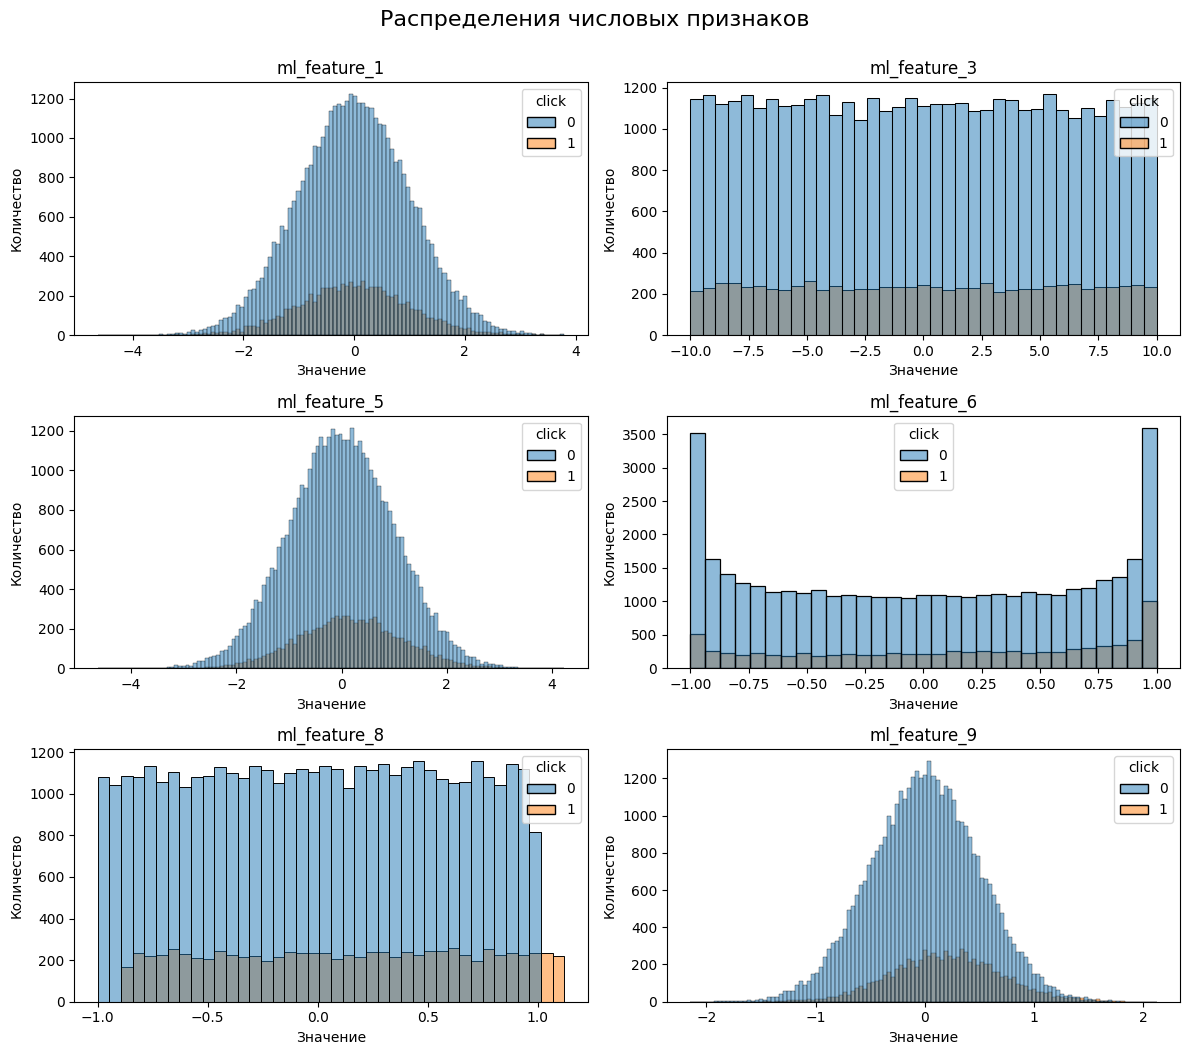

,ml_feature_1,ml_feature_3,ml_feature_5,ml_feature_6,ml_feature_8,ml_feature_9,ml_feature_10
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,-0.002445,-0.036381,0.034729,0.022948,0.025465,0.035361,0.020226
std,1.000280,5.792335,1.002116,0.656690,0.578026,0.505034,0.303309
min,-4.631262,-9.999742,-4.631853,-1.000000,-0.999965,-2.147526,-1.287965
25%,-0.677784,-5.059555,-0.639829,-0.579775,-0.470627,-0.304077,-0.182386
50%,-0.003776,-0.056155,0.028112,0.037786,0.027348,0.035985,0.018930
75%,0.673534,4.985939,0.707594,0.637131,0.521117,0.374152,0.224080
max,3.793828,9.999975,4.230623,1.000000,1.119858,2.120786,1.202300


In [8]:
fig, axes = plt.subplots(len(num_features) // 2, 2, figsize=(12, len(num_features) * 1.5))

for i, ax in enumerate(axes.flatten()):
    draw_histogram_grid(
            df,
            num_features[i],
            num_features[i], 
            "Значение", 
            "Количество", 
            **{'ax': ax,
               'hue': 'click'})
plt.suptitle("Распределения числовых признаков", fontsize=16, y=1)
plt.tight_layout()
plt.show()

display(df[num_features].describe())

- Распределения признаков `ml_feature_1`, `ml_feature_5`, `ml_feature_9` близки к нормальным. Классы целевой переменной распределены так же (у `ml_feature_9` распределение кликов немного сдвинуто вправо).
- Распределения признаков `ml_feature_3`, `ml_feature_8` близки к равномерным, как и распределения количества кликов по этим признакам. Признак `ml_feature_3` бесполезен для обучения и может быть удален.
- Значения `ml_feature_8`, соответствующие положительному классу, сдвинуты вправо относительно значений нулевого класса и выходят за пределы интервала $[-1, 1]$. Вероятно, для записей, относящихся к положительному классу, этот признак указан с ошибкой. Если это действительно так, данный признак тоже должен быть удален, потому что ошибочные значения приведут к неправильному обучению модели. Однако на предоставленном датасете распределения обучающей и тестовой выборок будут совпадать, поэтому в рамках данного проекта признак `ml_feature_8` будет оставлен в неизменном виде.

Разобьем признак `hours` на составляющие: месяц, день и час и построим диаграммы распределения этих признаков.

,raw_hour,month,day,hour,click
0,14102100,1410,21,0,1
1,14102100,1410,21,0,0
2,14102100,1410,21,0,0
3,14102100,1410,21,0,0
4,14102100,1410,21,0,0


Количество уникальных значений:


raw_hour    240
month         1
day          10
hour         24
click         2
dtype: int64

Распределение доли кликов по часам:


count    24.000000
mean      0.172816
std       0.012918
min       0.148988
25%       0.163071
50%       0.173535
75%       0.184231
max       0.193576
Name: click, dtype: float64

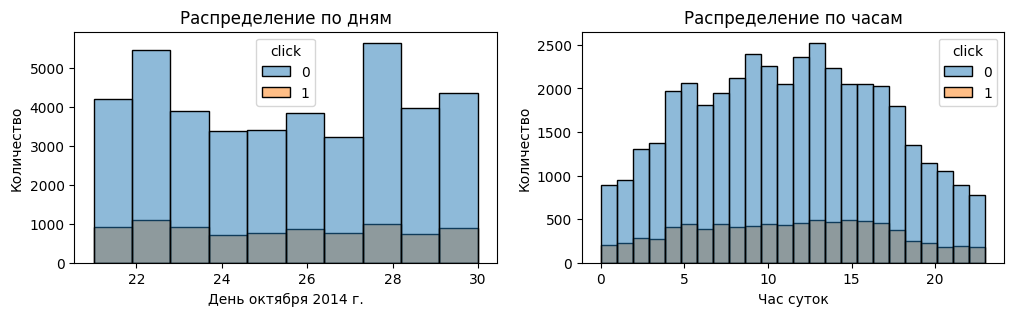

In [9]:
df_hours = pd.DataFrame({
    'raw_hour': df['hour'],
    'month': df['hour'] // 10000,
    'day': df['hour'] % 10000 // 100,
    'hour': df['hour'] % 100,
    'click': df['click']
})

display(df_hours.head())

print("Количество уникальных значений:")
display(df_hours.nunique())

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
draw_histogram_grid(
            df_hours,
            'day',
            "Распределение по дням", 
            "День октября 2014 г.", 
            "Количество", 
            ax = axes[0],
            hue = 'click',
            bins = df_hours['day'].nunique())

draw_histogram_grid(
            df_hours,
            'hour',
            "Распределение по часам", 
            "Час суток", 
            "Количество", 
            ax = axes[1],
            hue = 'click',
            bins = df_hours['hour'].nunique())

print("Распределение доли кликов по часам:")
display(df_hours.groupby(by='hour')['click'].mean().describe())

- Данные собраны за 10 дней октября 2014 года. Количество дней слишком мало, чтобы установить недельные или месячные колебания целевой переменной. Единственным признаком, который можно взять для машинного обучения является час суток. 
- На диаграмме видны суточные колебания количества обращений - основной объем приходится на часы с 4 по 18, однако доля кликов различается незначительно - ее стандартное отклонение по часам равно 0.01.

Изучим корреляции признаков между собой и с целевой переменной. Среди признаков есть категориальные с большим количеством значений. Для лучшей эффективности анализа заменим их на Target Encoding (посчитаем среднее значение класса для каждой категории).

**NB:** Значения Target Encoding, получаемые на этом этапе, не будут использоваться при обучении модели, поэтому утечки данных не возникнет. Кодирование используется только для более эффективного вычисления корреляции между признаками.

interval columns not set, guessing: ['click', 'C1', 'banner_pos', 'site_id', 'site_domain', 'app_id', 'app_domain', 'device_model', 'device_type', 'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'ml_feature_1', 'ml_feature_4', 'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10', 'hour']


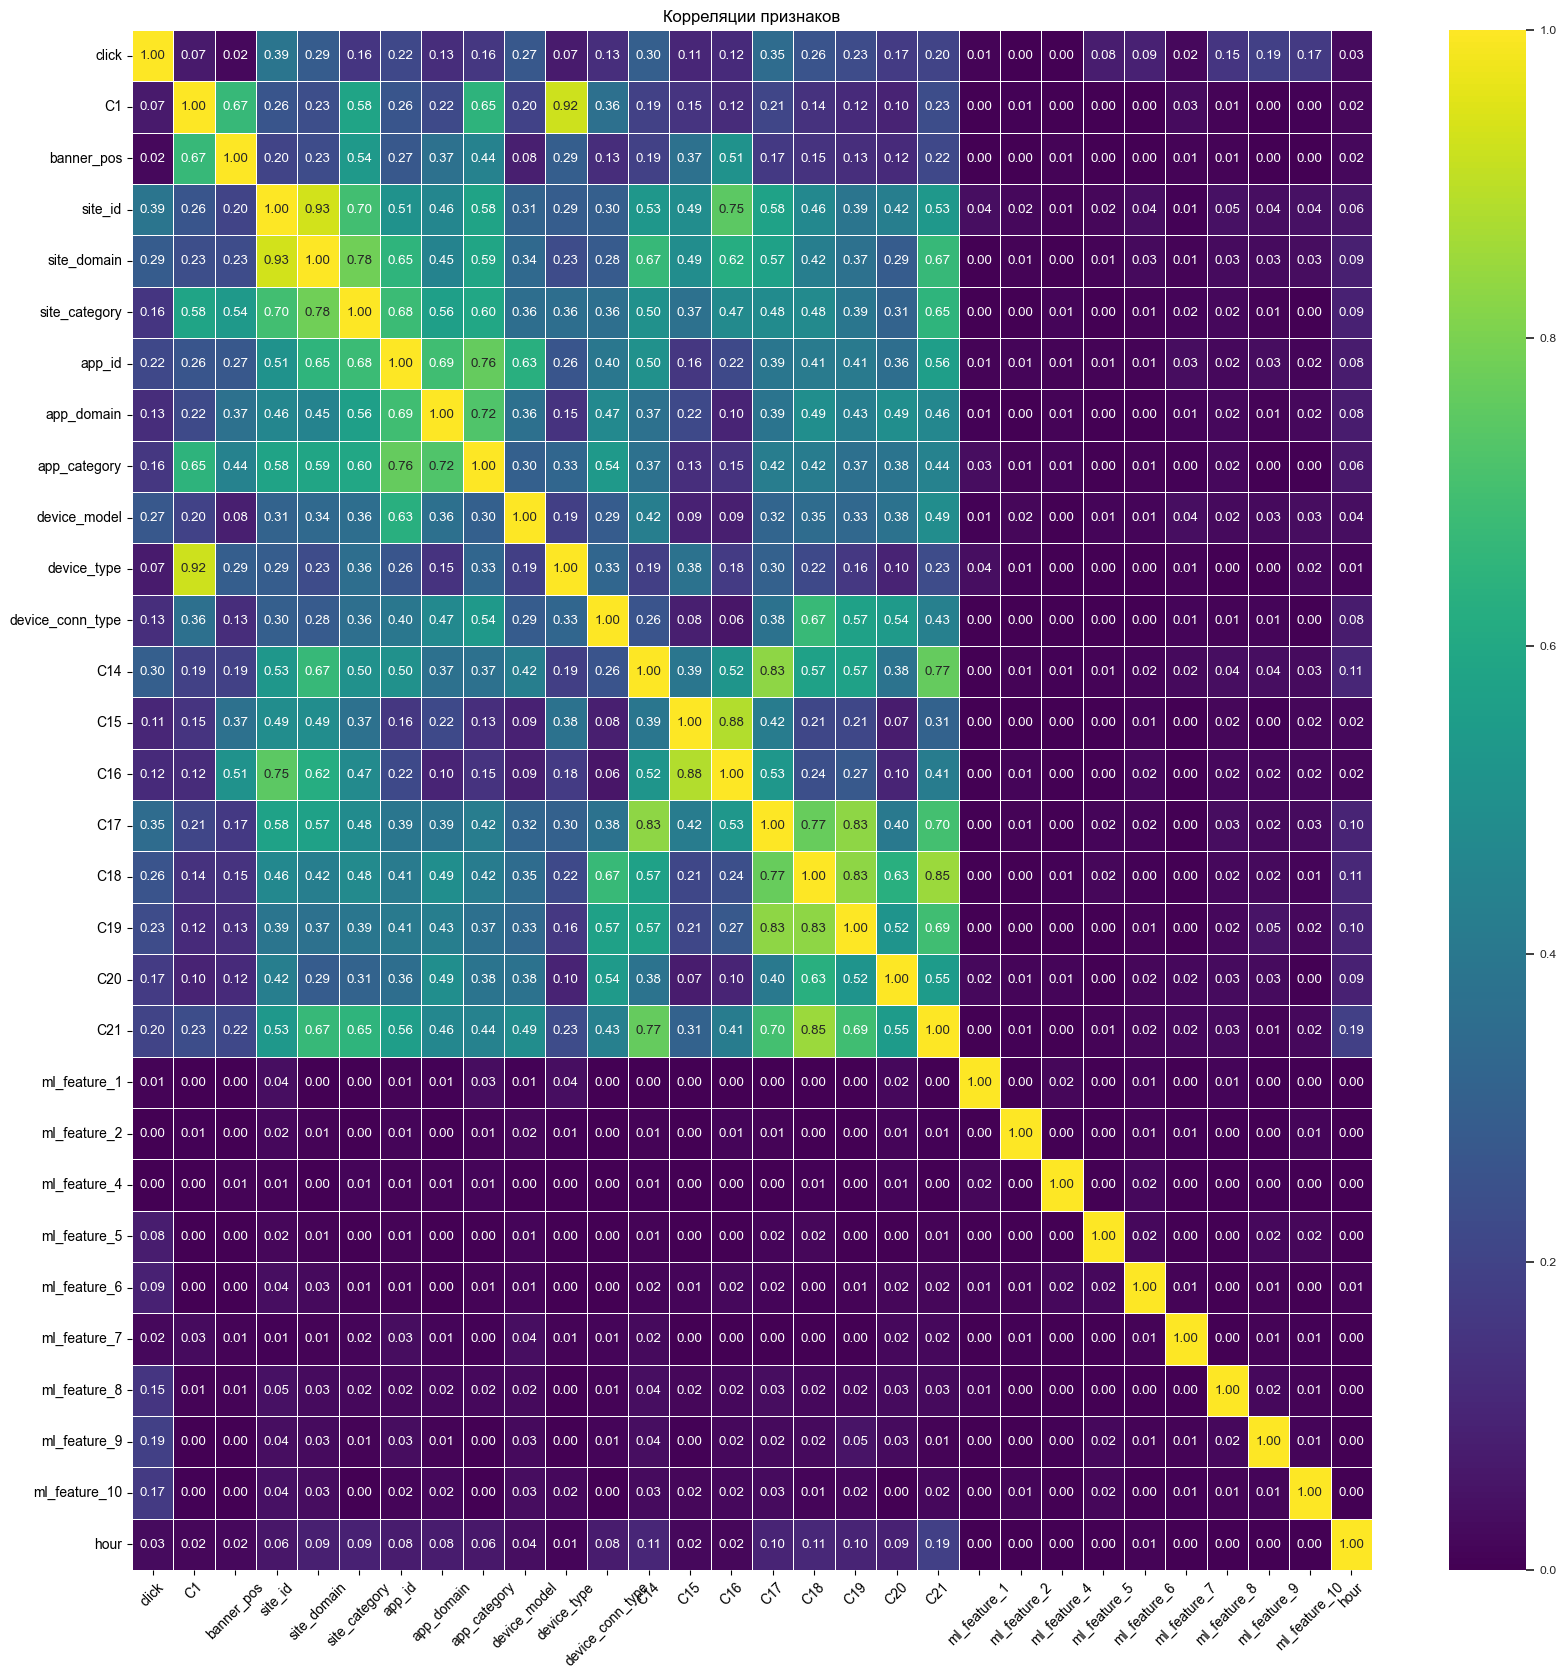

In [10]:
# Заменяем колонку hour на час суток
corr_df = pd.concat([df.drop(columns=['hour']),
                    df_hours['hour']], axis=1)

# Получаем признаки с количеством значений более 30
cat_card = df[cat_features].nunique() > 30
card_cols = cat_card[cat_card].index.to_list()

# Кодируем признаки с использованием Target Encoding
for col in card_cols:
    target_mean = corr_df.groupby(col)['click'].mean()
    corr_df[col] = corr_df[col].map(target_mean)
corr_df.drop(columns=['id', 'device_id', 'device_ip', 'ml_feature_3'], inplace=True)

# Вычисление корреляции при помощи φk
phik_matrix = phik.phik_matrix(corr_df)
draw_heatmap(phik_matrix, "Корреляции признаков", figsize=(20, 20))

- Корреляция целевой переменной со всеми признаками довольно слабая, максимальное значение, 0.39 - с признаком `site_id`. Следующие признаке по силе корреляции - `C17`, `C14`, `site_domain`.
- Сильно коррелируют между собой `C1` и `device_type`, а также `site_domain` и `site_id`. Из этих двух пар можно оставить по одному признаку.
- Присутствуют сильные корреляции внутри группы признаков `C14`-`C21`. Поскольку признаки анонимизированы, и их смысл неясен, предлагается их оставить до этапа отбора признаков.

#### Выводы:
1. Количество записей в исходном датасете - 50000. Пропуски и явные дубликаты отсутствуют.
2. Датасет содержит 33 признака и одну целевую переменную (`click`).
3. Классы целевой переменной несбалансированы. Положительный класс (переход пользователя по ссылке) составляет 17.21% от всех показов рекламы.
4. По результатам анализа распределения признаков было решено удалить дискретные признаки `id`, `device_id`, `device_ip`, непрерывный числовой признак `ml_feature_3`, распределенный равномерно относительно целевой переменной, а также признак `hour`.
5. По результатам анализа корреляций установлено, что наибольшая корреляция целевой переменной наблюдается с признаками `site_id`, `C17`, `C14`, `site_domain`, однако максимальное значение корреляции невелико - 0.39.
6. Пары признаков `C1` и `device_type`, а также `site_domain` и `site_id` сильно коррелируют между собой. Из этих двух пар можно оставить по одному признаку.
7. Категориальные признаки с количеством значений от 3 до 9 могут быть закодированы при помощи One-Hot Encoding, для признаков с большим количеством значений следует использовать метод Target Encoding.

## 3. Разделение данных на выборки

#### 3.1 Разделение данных

- Разделим датасет на обучающую и тестовую выборки:

In [11]:
# Числовые признаки
num_features = ['ml_feature_1',
#                'ml_feature_3',
                'ml_feature_5',
                'ml_feature_6',
                'ml_feature_8',
                'ml_feature_9',
                'ml_feature_10']

# Таргет
target = 'click'

# Категориальные признаки
cat_features = [#'C1',
                'C14',
                'C15',
                'C16',
                'C17',
                'C18',
                'C19',
                'C20',
                'C21',
                'app_category',
                'app_domain',
                'app_id',
                'banner_pos',
                'device_conn_type',
#                'device_id',
#                'device_ip',
                'device_model',
                'device_type',
                'hour',
                'ml_feature_2',
                'ml_feature_4',
                'ml_feature_7',
                'site_category',
#                'site_domain',
                'site_id']

all_features = num_features + cat_features

X = df[all_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    shuffle=True, 
                                                    stratify=y, 
                                                    random_state=RANDOM_SEED)

train_pos_ratio = y_train.sum() / len(y_train)
print(f"Положительный класс в исходном датасете: {y.sum().sum() / len(y) * 100:.2f}%")
print(f"Положительный класс в train: {y_train.sum().sum() / len(y_train) * 100:.2f}%")
print(f"Положительный класс в test: {y_test.sum().sum() / len(y_test) * 100:.2f}%")
print(f"Размеры выборок: train: {len(y_train)}, test: {len(y_test)}")

Положительный класс в исходном датасете: 17.21%
Положительный класс в train: 17.21%
Положительный класс в test: 17.21%
Размеры выборок: train: 40000, test: 10000


Разделение проведено, доля положительного класса в обеих выборках совпадает с долей в исходном датасете.

## 4. Предобработка данных — построение пайплайнов

Опишем функцию для создания пайплайна с предобработкой и классификатором:
- Для числовых признаков проведем масштабирование (стандартизацию)
- Кодирование категориальных признаков с количеством значений менее 10 при помощи One-Hot Encoding, признаков с большим количеством значений - Target Encoding.

In [12]:
# Функция для извлечения часа из признака hour
def hour_extractor(X):
    X = X.copy()
    X['hour'] = X['hour'] % 100
    return X

# Функция для создания пайплайна предобработки
def create_pp_pipeline(feature_num_cols, ohe_cols, target_enc_cols, feature_engineering):
    # Собранный препроцессинг
    rv = Pipeline([
                    ('ct', ColumnTransformer([
                        ('hour_extract', FunctionTransformer(hour_extractor), ['hour']),
                        ('cat_ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ohe_cols),
                        ('cat_target', TargetEncoder(random_state=RANDOM_SEED), target_enc_cols),
                        ('num', StandardScaler(), feature_num_cols)
                    ])),
                    ('feature_eng', FunctionTransformer(feature_engineering, validate=False))])

    rv.set_output(transform="pandas")
    return rv

# Функция для создания пайплайна предобработки и классификации
def create_pipeline(feature_num_cols, ohe_cols, target_enc_cols, feature_engineering, classifier):
    preprocess = create_pp_pipeline(feature_num_cols, ohe_cols, target_enc_cols, feature_engineering)

    return Pipeline([
        ('preprocess', preprocess),
        ('classify', classifier)
    ])

cat_card = X_train[cat_features].nunique()
cat_ohe_features = cat_card[(cat_card > 2) & (cat_card < 10)].index.to_list()
cat_te_features = cat_card[cat_card >= 10].index.to_list()
print("Признаки для кодирования OHE:")
display(cat_ohe_features)
print("Признаки для кодирования Target Enconding:")
display(cat_te_features)

Признаки для кодирования OHE:


['C15',
 'C16',
 'C18',
 'banner_pos',
 'device_conn_type',
 'device_type',
 'ml_feature_2',
 'ml_feature_7']

Признаки для кодирования Target Enconding:


['C14',
 'C17',
 'C19',
 'C20',
 'C21',
 'app_category',
 'app_domain',
 'app_id',
 'device_model',
 'hour',
 'site_category',
 'site_id']

Былп написана функция создания пайплайна с предобработкой и моделью классификации, определены признаки для кодирования методами One-Hot Encoding, Target Encoding.

## 5. Отбор признаков

#### 5.1 Фильтрационные методы
- Выведем корреляцию целевой переменной с признаками: 

interval columns not set, guessing: ['hour_extract__hour', 'cat_ohe__C15_120', 'cat_ohe__C15_216', 'cat_ohe__C15_300', 'cat_ohe__C15_320', 'cat_ohe__C15_480', 'cat_ohe__C15_728', 'cat_ohe__C15_768', 'cat_ohe__C15_1024', 'cat_ohe__C16_20', 'cat_ohe__C16_36', 'cat_ohe__C16_50', 'cat_ohe__C16_90', 'cat_ohe__C16_250', 'cat_ohe__C16_320', 'cat_ohe__C16_480', 'cat_ohe__C16_768', 'cat_ohe__C16_1024', 'cat_ohe__C18_0', 'cat_ohe__C18_1', 'cat_ohe__C18_2', 'cat_ohe__C18_3', 'cat_ohe__banner_pos_0', 'cat_ohe__banner_pos_1', 'cat_ohe__banner_pos_2', 'cat_ohe__banner_pos_3', 'cat_ohe__banner_pos_4', 'cat_ohe__banner_pos_5', 'cat_ohe__banner_pos_7', 'cat_ohe__device_conn_type_0', 'cat_ohe__device_conn_type_2', 'cat_ohe__device_conn_type_3', 'cat_ohe__device_conn_type_5', 'cat_ohe__device_type_0', 'cat_ohe__device_type_1', 'cat_ohe__device_type_4', 'cat_ohe__device_type_5', 'cat_ohe__ml_feature_2_A', 'cat_ohe__ml_feature_2_B', 'cat_ohe__ml_feature_2_C', 'cat_ohe__ml_feature_2_D', 'cat_ohe__ml_feature

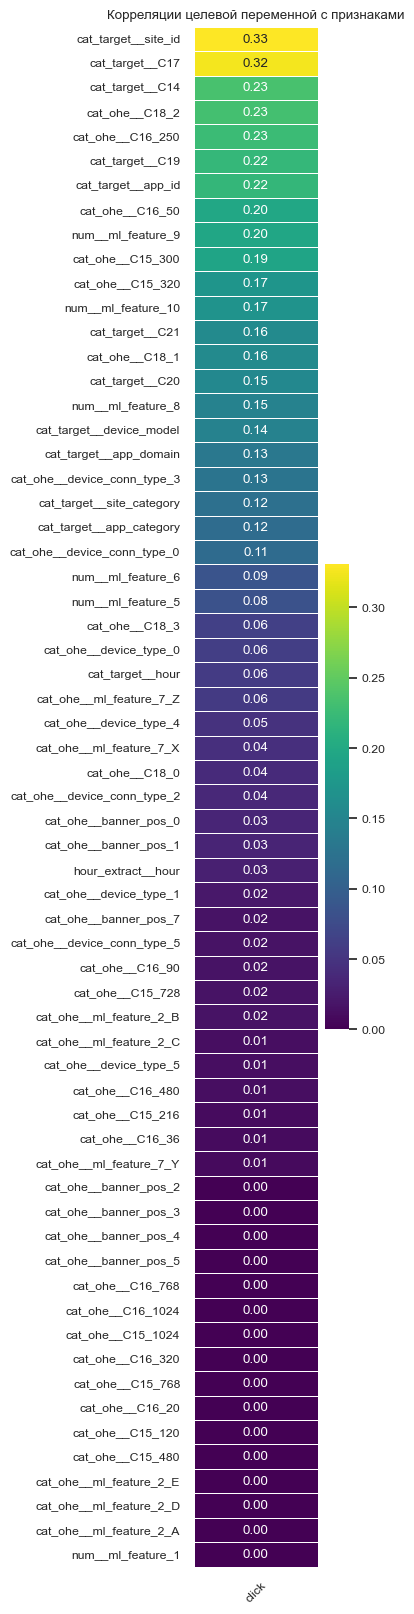

In [13]:
pp = create_pp_pipeline(num_features, cat_ohe_features, cat_te_features, lambda X: X)
X_train_pp = pp.fit_transform(X_train, y_train)
X_train_pp.index = y_train.index
# corr_matrix = (np.abs(pd.concat([X_train_corr, y_train], axis=1)
#                .corr(method='spearman')[[target]])
#                .sort_values(by=target, ascending=False))

corr_matrix = (phik.phik_matrix(pd.concat([X_train_pp, y_train], axis=1))[[target]]
               .sort_values(by=target, ascending=False)
               .drop(target))
#corr_matrix = pd.concat([X_train_corr, y_train], axis=1).corr()
draw_heatmap(corr_matrix, "Корреляции целевой переменной с признаками", figsize=(2, 20))

- Получим список признаков с корреляцией 0.20 и более:

In [14]:
corr_threshold = 0.20
n_features_to_select = (round(corr_matrix[target], 2) >= corr_threshold).sum()
features_to_keep_corr = set(corr_matrix[:n_features_to_select].index.to_list())

print(f"Признаки с корреляцией {corr_threshold:.2f} и выше:")
display(features_to_keep_corr)

# Примем за максимальное полученное на этом шаге количество признаков
n_features_to_select = len(features_to_keep_corr)

Признаки с корреляцией 0.20 и выше:


{'cat_ohe__C16_250',
 'cat_ohe__C16_50',
 'cat_ohe__C18_2',
 'cat_target__C14',
 'cat_target__C17',
 'cat_target__C19',
 'cat_target__app_id',
 'cat_target__site_id',
 'num__ml_feature_9'}

- Получим список числовых признаков с низкой дисперсией:

In [15]:
vs_constant = VarianceThreshold(threshold=0.01) 
vs_constant.fit(X_train[num_features])
features_to_delete_const = {X for X, keep in zip(X_train_pp.columns,
                                                 vs_constant.get_support()) if not keep}
print("Константные признаки (дисперсия < 0.01):")
display(features_to_delete_const)

Константные признаки (дисперсия < 0.01):


set()

Константных числовых  признаков нет.

- Получим признаки с максимальной метрикой взаимной информации с целевой переменной:

In [16]:
mi_scores = mutual_info_classif(X_train_pp, y_train, random_state=RANDOM_SEED)
print(len(mi_scores))
top_idx = sorted(range(len(X_train_pp.columns)), 
                 key = lambda i: mi_scores[i], reverse=True)[:n_features_to_select]
features_to_keep_mi = {X_train_pp.columns[i] for i in top_idx}

print("Признаки с максимальной Mutual Information:")
display(features_to_keep_mi)

63
Признаки с максимальной Mutual Information:


{'cat_ohe__C16_50',
 'cat_target__C14',
 'cat_target__C17',
 'cat_target__C19',
 'cat_target__C21',
 'cat_target__app_domain',
 'cat_target__app_id',
 'cat_target__site_id',
 'num__ml_feature_8'}

#### 5.2 Отбор при помощи методов-обёрток

- Запустим отбор признаков при помощи методов-обёрток:

In [17]:
lr_estimator = LogisticRegression(random_state=RANDOM_SEED, solver='liblinear')

rfe_selector = RFE(lr_estimator, step=1, n_features_to_select=n_features_to_select)

rfe_selector.fit(X_train_pp, y_train)
features_to_keep_lr_rfe = {X for X, keep in zip(X_train_pp.columns, 
                                                  rfe_selector.get_support()) if keep}

print("Наиболее важные признаки согласно RFE:")
display(features_to_keep_lr_rfe)

# 10 наиболее важных признаков по SFS
lr_estimator2 = LogisticRegression(random_state=RANDOM_SEED, solver='liblinear')
sfs_selector = SFS(lr_estimator2, k_features=n_features_to_select, cv=5, 
                   scoring='f1', n_jobs=-1)
sfs_selector.fit(X_train_pp, y_train)
features_to_keep_lr_sfs = set(sfs_selector.k_feature_names_)

print("Наиболее важные признаки согласно SFS:")
display(features_to_keep_lr_sfs)

Наиболее важные признаки согласно RFE:


{'cat_ohe__ml_feature_7_X',
 'cat_ohe__ml_feature_7_Y',
 'cat_ohe__ml_feature_7_Z',
 'cat_target__C17',
 'cat_target__C20',
 'cat_target__app_id',
 'cat_target__hour',
 'cat_target__site_category',
 'cat_target__site_id'}

Наиболее важные признаки согласно SFS:


{'cat_ohe__ml_feature_7_Z',
 'cat_target__C17',
 'cat_target__app_id',
 'cat_target__site_id',
 'num__ml_feature_10',
 'num__ml_feature_5',
 'num__ml_feature_6',
 'num__ml_feature_8',
 'num__ml_feature_9'}

#### 5.3 Создание финального набора признаков
- Для дальнейшего обучения объединим существенные признаки, выявленные на предыдущих этапах:

In [18]:
selected_features = (features_to_keep_mi |
                    features_to_keep_corr |
                    features_to_keep_lr_rfe |
                    features_to_keep_lr_sfs) - features_to_delete_const

print(f"Осталось {len(selected_features)} признаков из {len(X_train_pp.columns)}: ")
display(selected_features)

Осталось 21 признаков из 63: 


{'cat_ohe__C16_250',
 'cat_ohe__C16_50',
 'cat_ohe__C18_2',
 'cat_ohe__ml_feature_7_X',
 'cat_ohe__ml_feature_7_Y',
 'cat_ohe__ml_feature_7_Z',
 'cat_target__C14',
 'cat_target__C17',
 'cat_target__C19',
 'cat_target__C20',
 'cat_target__C21',
 'cat_target__app_domain',
 'cat_target__app_id',
 'cat_target__hour',
 'cat_target__site_category',
 'cat_target__site_id',
 'num__ml_feature_10',
 'num__ml_feature_5',
 'num__ml_feature_6',
 'num__ml_feature_8',
 'num__ml_feature_9'}

#### Выводы:
- Отбор признаков для обучения был произведен с использованием следующих методов:
    1. Изучение корреляций признаков с целевой переменной.
    2. Изучение дисперсии числовых признаков.
    3. Изучение метрики Mutual Information с целевой переменной.
    4. Использование метода прямого отбора признаков с моделью логистической регресии и кросс-валидацией.
    5. Использование метода рекурсивного исключения признаков с моделью логистической регресии и кросс-валидацией.
- Наборы лучших признаков по всем методам были объединены, для обучения были оставлены 36 признаков из 63.

## 6. Обучение базовой модели

### 6.1 Обучение `DummyClassifier`

- Обучим базовую модель на основе `DummyClassifier`:

In [19]:
# Функция, удаляющая лишние признаки
def optimize_features(X):
    X_new = X[list(selected_features)].copy()
    return X_new

# Функция для расчета метрик
def calc_metrics(y, y_pred_proba, threshold=0.5, prefix='train_'):
    y_pred = (y_pred_proba >= threshold)
    return {(prefix + 'accuracy'): accuracy_score(y, y_pred),
            (prefix + 'f1'): f1_score(y, y_pred),
            (prefix + 'average_precision'): average_precision_score(y, y_pred_proba),
            (prefix + 'precision'): precision_score(y, y_pred, zero_division=0),
            (prefix + 'recall'): recall_score(y, y_pred),
            (prefix + 'neg_log_loss'): -log_loss(y, y_pred_proba),
            (prefix + 'brier_loss'): brier_score_loss(y, y_pred_proba)}    

dummy_pipeline = create_pipeline(num_features,
                                 cat_ohe_features,
                                 cat_te_features,
                                 optimize_features,
                                 DummyClassifier(random_state=RANDOM_SEED))

dummy_pipeline.fit(X_train, y_train)
y_train_proba_dummy = dummy_pipeline.predict_proba(X_train)[:, 1]
dummy_metrics = calc_metrics(y_train, y_train_proba_dummy)
display(pd.DataFrame({
    'DummyRegression': dummy_metrics}))

,DummyRegression
train_accuracy,0.827950
train_f1,0.000000
train_average_precision,0.172050
train_precision,0.000000
train_recall,0.000000
train_neg_log_loss,-0.459122
train_brier_loss,0.142449


### 6.2 Обучение модели логистической регрессии

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

lr_pipeline = create_pipeline(num_features,
                            cat_ohe_features,
                            cat_te_features,
                            optimize_features,
                            LogisticRegression(random_state=RANDOM_SEED))

lr_metrics = cross_validate(lr_pipeline, 
                            X_train, 
                            y_train, 
                            scoring=['accuracy',
                                        'f1',
                                        'average_precision',
                                        'precision',
                                        'recall',
                                        'neg_log_loss'],
                            cv=cv,
                            return_train_score = True,
                            return_estimator = True,
                            n_jobs=-1)

display(pd.DataFrame({
    'DummyRegression': dummy_metrics,
    'LogisticRegression': pd.DataFrame(lr_metrics).iloc[:, 3:].mean()}))

,DummyRegression,LogisticRegression
test_accuracy,NaN,0.837550
test_average_precision,NaN,0.420675
test_f1,NaN,0.237379
test_neg_log_loss,NaN,-0.391800
test_precision,NaN,0.617556
test_recall,NaN,0.147050
train_accuracy,0.827950,0.846856
train_average_precision,0.172050,0.501421
train_brier_loss,0.142449,NaN
train_f1,0.000000,0.293471


### 6.3 Обучение модели SVM

- Обучим модель SVM и сравним ее с базовой и логистической регрессией:

In [21]:
svc_pipeline = create_pipeline(num_features,
                            cat_ohe_features,
                            cat_te_features,
                            optimize_features,
                            SVC(kernel='linear', 
                                probability=False,
                                random_state=RANDOM_SEED))

svc_metrics = cross_validate(svc_pipeline, 
                            X_train, 
                            y_train, 
                            scoring=['accuracy',
                                        'f1',
                                        'average_precision',
                                        'precision',
                                        'recall'],
                            cv=cv,
                            return_train_score = True,
                            return_estimator = True,
                            n_jobs=-1)

display(pd.DataFrame({
    'DummyRegression': dummy_metrics,
    'LogisticRegression': pd.DataFrame(lr_metrics).iloc[:, 3:].mean(),
    'SVM': pd.DataFrame(svc_metrics).iloc[:, 3:].mean()}))

,DummyRegression,LogisticRegression,SVM
test_accuracy,NaN,0.837550,0.827950
test_average_precision,NaN,0.420675,0.355900
test_f1,NaN,0.237379,0.000000
test_neg_log_loss,NaN,-0.391800,NaN
test_precision,NaN,0.617556,0.000000
test_recall,NaN,0.147050,0.000000
train_accuracy,0.827950,0.846856,0.827950
train_average_precision,0.172050,0.501421,0.441703
train_brier_loss,0.142449,NaN,NaN
train_f1,0.000000,0.293471,0.000000


#### Выводы:
- Модель логистической регрессии с гиперпараметрами по умолчанию показывает лучшие результаты по всем метрикам, чем базовая `DummyClassifier`. Основная метрика PR-AUC у логистической регрессии больше в 3 раза.
- Неоткалиброванная модель SVM с линейным ядром и гиперпараметрами по умолчанию показывает результат по метрике PR-AUC лучше, чем базовая (0.45 против 0.17), но хуже, чем логистическая регрессия (0.45 против 0.51). По метрике `accuracy` SVM находится на уровне базовой модели. Можно попробовать улучшить результаты подбором гиперпараметров.

## 7. Подбор гиперпараметров: Grid Search с кросс-валидацией
#### 7.1 Определение сеток гиперпараметров
- Определим сетку гиперпараметров для логистической регрессии:
    1. `l1_ratio` - регуляризация L1 (`l1_ratio` = 1), L2 (`l1_ratio` = 0) или `elasticnet` (комбинация L1 и L2, поддерживается солвером `saga`).
    2. `C` - сила регуляризации (меньшие значения соответствуют более сильной регуляризации).

In [22]:
lr_param_grid = [
    {
        "solver": ['liblinear'],
        "l1_ratio": [0, 1],
        "C": [0.01, 0.1, 1, 10, 100]
    },
    {
        "solver": ['saga'],
        "l1_ratio": [0, 0.5, 1],
        "C": [0.1, 1, 10]
    }
]

- Сетка параметров для SVM:
    1. `kernel` - тип ядра.
    2. `C` - сила регуляризации (меньшие значения соответствуют более сильной регуляризации).
    3. Для ядер `rbf`, `poly`, `sigmoid` параметр `gamma` - "радиус влияния" точек обучающей выборки на разделяющую гиперповерхность.
    4. Для ядра `poly` параметр `degree` - степень полинома, параметр `coef0` - свободный член.

In [23]:
svc_param_grid = [
    {
        "kernel": ['linear'],
        "C": [0.1, 1, 10]
    },
    {
        "kernel": ['rbf'],
        "gamma": ['auto', 'scale'],
        "C": [0.1, 1, 10]
    }
    # {
    #     "kernel": ['poly'],
    #     "svc_gamma": ['auto', 'scale'],
    #     "C": [0.1, 1, 10],
    #     "degree": [2, 3],
    #     "coef0": [0, 0.5, 1]
    # }
]

- Выполним поиск по сетке гиперпараметров логистической регрессии:

In [24]:
# Получаем обучающую выборку с сокращенным набором признаков
X_train_pp_opt = optimize_features(X_train_pp)

# Поиск по сетке параметров
lr_grid = GridSearchCV(estimator=LogisticRegression(random_state=42), 
                    param_grid=lr_param_grid, 
                    cv=cv, 
                    scoring='average_precision', 
                    n_jobs=-1, 
                    verbose=1) 
lr_grid.fit(X_train_pp_opt, y_train)


# Обработка результатов
def top_10_results(lr_grid):
    lr_grid_results = pd.DataFrame(lr_grid.cv_results_)
    lr_grid_results = lr_grid_results.sort_values(by=["rank_test_score"])
    lr_grid_results = lr_grid_results.set_index(
    lr_grid_results["params"].apply(lambda x: "_".join(str(val) for val in x.values()))
        ).rename_axis("kernel")
    display(lr_grid_results[["params", "rank_test_score", "mean_test_score", "std_test_score"]][:10])

top_10_results(lr_grid)

# Лучшие параметры
lr_best_params = lr_grid.best_params_

Fitting 5 folds for each of 19 candidates, totalling 95 fits


,params,rank_test_score,mean_test_score,std_test_score
kernel,,,,
0.1_0.5_saga,"{'C': 0.1, 'l1_ratio': 0.5, 'solver': 'saga'}",1,0.421352,0.005112
0.1_0_liblinear,"{'C': 0.1, 'l1_ratio': 0, 'solver': 'liblinear'}",2,0.421181,0.005802
0.1_0_saga,"{'C': 0.1, 'l1_ratio': 0, 'solver': 'saga'}",3,0.421173,0.005262
0.1_1_saga,"{'C': 0.1, 'l1_ratio': 1, 'solver': 'saga'}",4,0.420554,0.005517
0.1_1_liblinear,"{'C': 0.1, 'l1_ratio': 1, 'solver': 'liblinear'}",5,0.420466,0.005600
1_0_saga,"{'C': 1, 'l1_ratio': 0, 'solver': 'saga'}",6,0.420243,0.005051
1_0_liblinear,"{'C': 1, 'l1_ratio': 0, 'solver': 'liblinear'}",7,0.420196,0.005148
1_0.5_saga,"{'C': 1, 'l1_ratio': 0.5, 'solver': 'saga'}",8,0.420054,0.005114
1_1_liblinear,"{'C': 1, 'l1_ratio': 1, 'solver': 'liblinear'}",9,0.419958,0.005233


- Поиск по сетке параметров SVM:

In [25]:
svc_grid = GridSearchCV(estimator=SVC(random_state=42), 
                    param_grid=svc_param_grid, 
                    cv=cv, 
                    scoring='average_precision', 
                    n_jobs=-1, 
                    verbose=4) 
svc_grid.fit(X_train_pp_opt, y_train)

top_10_results(svc_grid)

# Лучшие параметры
svc_best_params = svc_grid.best_params_

Fitting 5 folds for each of 9 candidates, totalling 45 fits


,params,rank_test_score,mean_test_score,std_test_score
kernel,,,,
10_auto_rbf,"{'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}",1,0.383233,0.010138
1_auto_rbf,"{'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}",2,0.372815,0.008548
1_scale_rbf,"{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}",3,0.372054,0.008567
0.1_auto_rbf,"{'C': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}",4,0.370652,0.009149
10_scale_rbf,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",5,0.369357,0.005860
0.1_scale_rbf,"{'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}",6,0.365891,0.008815
0.1_linear,"{'C': 0.1, 'kernel': 'linear'}",7,0.351434,0.015184
1_linear,"{'C': 1, 'kernel': 'linear'}",8,0.339499,0.030493
10_linear,"{'C': 10, 'kernel': 'linear'}",9,0.321019,0.053403


#### Вывод:
- Был выполнен подбор гиперпараметров моделей логистической регрессии и SVM для оптимизации метрики PR-AUC.
- Модель SVM с лучшим набором гиперпараметров показала худший результат, чем логистическая регрессия с первыми 10 наборами гиперпараметров.
- В качестве финальной выбирается модель логистической регрессии с параметрами `C` = 0.1, `l1_ratio` = 0.5 (регуляризация L2 и L1 с равными весами).

## 8. Финальная модель

#### 8.1 Обучение финальной модели
- Обучим модель логистической регрессии с лучшим набором параметров:

In [26]:
final_pipeline = create_pipeline(num_features,
                                 cat_ohe_features,
                                 cat_te_features,
                                 optimize_features,
                                 LogisticRegression(**lr_best_params))
final_pipeline.fit(X_train, y_train)
y_proba_test = final_pipeline.predict_proba(X_test)[:, 1]

- Таже обучим модель SVM с лучшим набором параметров:

In [27]:
final_svm_pipeline = create_pipeline(num_features,
                                 cat_ohe_features,
                                 cat_te_features,
                                 optimize_features,
                                 SVC(**svc_best_params))
final_svm_pipeline.fit(X_train, y_train)

y_pred_test_svm = final_svm_pipeline.predict(X_test)

# Сырые оценки SVC
y_scores_test_svm = final_svm_pipeline.decision_function(X_test)

#### 8.2 Подсчет метрик на тестовой выборке
- Посчитаем метрики логистической регрессии на тестовой выборке:

In [28]:
final_train_metrics = calc_metrics(y_train, final_pipeline.predict_proba(X_train)[:, 1], 
                                   prefix='test_')
final_test_metrics = calc_metrics(y_test, y_proba_test, prefix='test_')
display(pd.DataFrame({
    "Train": final_train_metrics,
    "Test": final_test_metrics}))

,Train,Test
test_accuracy,0.845500,0.833800
test_f1,0.278543,0.204023
test_average_precision,0.490837,0.397587
test_precision,0.708432,0.580381
test_recall,0.173351,0.123765
test_neg_log_loss,-0.372555,-0.399357
test_brier_loss,0.115239,0.124290


- Метрики SVM на тестовой выборке:

In [29]:
final_svm_train_metrics = calc_metrics(y_train, final_svm_pipeline.predict(X_train), 
                                   prefix='test_')
final_svm_test_metrics = calc_metrics(y_test, y_pred_test_svm, prefix='test_')
display(pd.DataFrame({
    "Train": final_svm_train_metrics,
    "Test": final_svm_test_metrics}))

print("Количество опорных векторов: ", len(final_svm_pipeline.named_steps['classify'].support_))

,Train,Test
test_accuracy,0.836475,0.831800
test_f1,0.142389,0.110994
test_average_precision,0.215983,0.199063
test_precision,0.728859,0.614035
test_recall,0.078901,0.061011
test_neg_log_loss,-5.894038,-6.062543
test_brier_loss,0.163525,0.168200


Количество опорных векторов:  14307


- Метрика `PR-AUC`, а также остальные метрики ухудшаются на тестовой выборке. Модель показывает небольшое переобучение.
- Баланс сдвинут в сторону точности (`precision`) в ущерб полноте (`recall`). Это соотношение можно регулировать порогом вероятности, однако на данном этапе это нецелесообразно, так как для заказчика важна калибровка модели и ее способность предсказывать вероятности.
- Модель SVM с ядром `rbf` работает очень долго из-за большого количества опорных векторов. При этом результаты хуже, чем у логистической регрессии, вероятно, из-за плохой разделимости классов и сложной границы.

#### 8.3 Анализ весов модели
- Определим самые важные признаки на основании абсолютных значений коэффициентов:

In [30]:
df_coef = pd.DataFrame({
    'coef': np.abs(final_pipeline.named_steps['classify'].coef_[0]),
    'Признак': X_train_pp_opt.columns.to_list()
}).sort_values(by='coef', ascending=False).reset_index(drop=True)

display(df_coef.style.background_gradient(cmap='viridis'))


,coef,Признак
0,3.203369,cat_target__app_id
1,2.762825,cat_target__site_id
2,2.130937,cat_target__C17
3,0.912803,cat_target__C14
4,0.840057,cat_target__C20
5,0.618341,cat_target__C21
6,0.489384,cat_target__C19
7,0.413651,num__ml_feature_9
8,0.376738,cat_target__hour
9,0.351082,num__ml_feature_10


Три наиболее важных признака совпадают с имеющими наибольшие коэффициенты корреляции с тестовой переменной.

#### Выводы:
- Для моделей логистической регрессии и SVM были подобраны гиперпараметры, на которых метрика PR-AUC достигает максимума.
- Модель логистической регрессии показала лучшие результаты на всех 10 лучших наборах, чем модель SVM с лучшими параметрами.
- Обе модели показывают худшие результаты на тестовой выборке и демонстрируют небольшое переобучение. У модели SVM дополнительным следствием переобучения является большая вычислительная нагрузка при предсказаниях из-за большого количества опорных векторов.
- Три наиболее важных признака совпадают с имеющими наибольшие коэффициенты корреляции с целевой переменной. Два из них - идентификаторы приложения и сайта. Эти параметры в наибольшей степени определяют вероятность клика.

## 9. Калибровка модели

#### 9.1 Проверка текущей калибровки

- Построим калибровочную кривую для логистической регрессии и SVM.
- Поскольку к SVM с параметром `probability`=`True` по умолчанию применяется калибровка Платта, будем использовать модель без этого параметра, а сырые оценки получать при помощи метода `decision_function()`

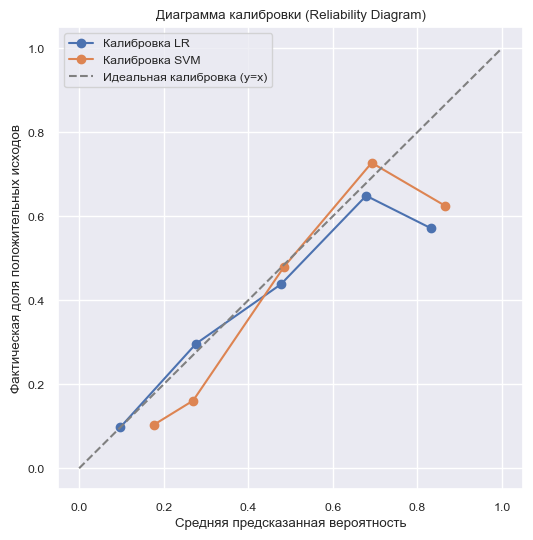

In [50]:
# Функция сигмоиды для отображения (-np.inf, np.inf) в (0, 1)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Вероятности для SVM
y_proba_test_svm = sigmoid(y_scores_test_svm)
lr_prob_true, lr_prob_pred = calibration_curve(y_test, y_proba_test)
svm_prob_true, svm_prob_pred = calibration_curve(y_test, y_proba_test_svm)

# Шаг 3: строим график
def draw_calib_curve(list):
    plt.figure(figsize=(6,6))
    for l in list:
        plt.plot(l[1], l[0], marker='o', label=l[2])

    plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Идеальная калибровка (y=x)')
    plt.xlabel('Средняя предсказанная вероятность')
    plt.ylabel('Фактическая доля положительных исходов')
    plt.title('Диаграмма калибровки (Reliability Diagram)')
    plt.legend()
    plt.grid(True)
    plt.show()

draw_calib_curve([(lr_prob_true, lr_prob_pred, "Калибровка LR"),
                  (svm_prob_true, svm_prob_pred, "Калибровка SVM")])

- Модель логистической регрессии откалибрована лучше, чем SVM, которая слишком оптимистична на небольших вероятностях.
- Обе модели плохо откалиброваны на вероятностях более 0.7 и ошибаются в сторону положительного класса (демонстрируют излишнюю уверенность).

#### 9.2 Применение методов калибровки
- Отделим от обучающей выборки калибровочную выборку, равную по объему тестовой:

In [34]:
X_train_2, X_calib, y_train_2, y_calib = train_test_split(X_train, 
                                                          y_train,
                                                          test_size=0.25, 
                                                          shuffle=True, 
                                                          stratify=y_train)

print(f"Размер обучающей выборки: {len(X_train_2)}, калибровочной: {len(X_calib)}.")

pp_calib = create_pp_pipeline(num_features, cat_ohe_features, cat_te_features, optimize_features)
X_train2_pp = pp_calib.fit_transform(X_train_2, y_train_2)

Размер обучающей выборки: 30000, калибровочной: 10000.


- Обучим модели логистической регрессии и SVM на обучающей выборке и откалибруем их на калибровочной выборке:

In [69]:
# Пайплайн для LR
lr_calib_pipeline = create_pipeline(num_features,
                                       cat_ohe_features,
                                       cat_te_features,
                                       optimize_features,
                                       LogisticRegression(**lr_best_params))
lr_calib_pipeline.fit(X_train_2, y_train_2)

# Пайплайн для SVM
svm_calib_pipeline = lr_calib_pipeline = create_pipeline(num_features,
                                       cat_ohe_features,
                                       cat_te_features,
                                       optimize_features,
                                       SVC(**svc_best_params))
lr_calib_pipeline.fit(X_train_2, y_train_2)

# Откалиброванный LR
lr_calibrated = CalibratedClassifierCV(FrozenEstimator(lr_calib_pipeline), 
                                       method='isotonic',
                                       cv=5)
lr_calibrated.fit(X_calib, y_calib)

# Откалиброванный SVM
svm_calibrated = CalibratedClassifierCV(FrozenEstimator(svm_calib_pipeline), 
                                       method='isotonic',
                                       cv=5)
svm_calibrated.fit(X_calib, y_calib)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",FrozenEstimat...ma='auto'))]))
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('ct', ...), ('feature_eng', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.Thi

- Получим предсказания калиброванных моделей и построим калибровочную кривую:

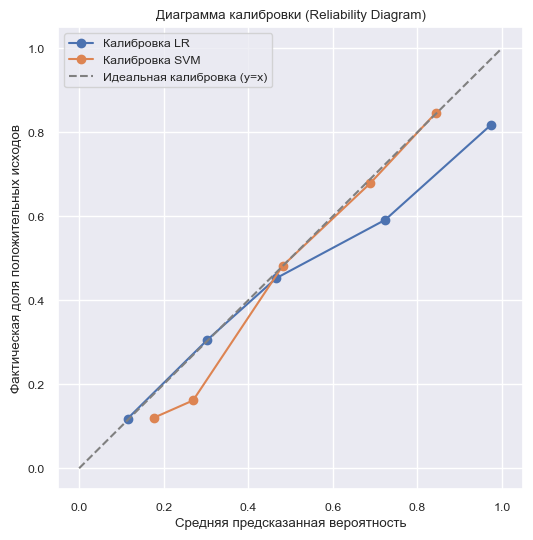

In [70]:
y_proba_test_calib = lr_calibrated.predict_proba(X_test)[:, 1]

y_proba_test_svm_calib = sigmoid(svm_calibrated.estimator.decision_function(X_test))

lr_prob_calib_true, lr_prob_calib_pred = calibration_curve(y_test, y_proba_test_calib)
svm_prob_calib_true, svm_prob_calib_pred = calibration_curve(y_test, y_proba_test_svm_calib)

draw_calib_curve([(lr_prob_calib_true, lr_prob_calib_pred, "Калибровка LR"),
                  (svm_prob_calib_true, svm_prob_calib_pred, "Калибровка SVM")])

- Получим оценки для обеих моделей:

In [71]:
lr_calib_metrics = calc_metrics(y_test, y_proba_test_calib, prefix='test_')
svm_calib_metrics = calc_metrics(y_test, y_proba_test_svm_calib, prefix='test_')

display(pd.DataFrame({'LogisticRegression': lr_calib_metrics,
                      'SVM': svm_calib_metrics}))

,LogisticRegression,SVM
test_accuracy,0.832300,0.832200
test_f1,0.194137,0.108395
test_average_precision,0.344700,0.361968
test_precision,0.561111,0.633540
test_recall,0.117374,0.059268
test_neg_log_loss,-0.424093,-0.474650
test_brier_loss,0.129223,0.147253


## 9. Калибровка модели

#### 9.1 Проверьте текущую калибровку
- Постройте калибровочную кривую, используйте `sklearn.calibration.calibration_curve`.
- Для обработки «сырых» значений SVC, нужно применить стандартную (необученную) сигмоиду для получения [0, 1].

#### 9.2 Примените методы калибровки
- Используйте `CalibratedClassifierCV` с методом `'isotonic'`.
- **Важно:** используйте для процедуры отдельную калибровочную выборку!

#### 9.3 Сравните модели до и после калибровки
- Посчитайте оценки Бриера для моделей до и после калибровки.
- Дополнительно можете рассчитать ECE и MCE для моделей до и после калибровки.
- Визуализируйте калибровочные кривые для моделей до и после калибровки.

## 10. Оценка качества калибровки

#### 10.1 Посчитайте метрики калибровки
- Оценка Бриера — средняя ошибка предсказанной вероятности.
- Дополнительная метрика ECE: среднее расхождение вероятностей.
- Дополнительная метрика MCE: максимальное расхождение вероятностей.

#### 10.2 Сравните модели до и после калибровки
- Выведите все метрики в одной таблице.
- Сделайте вывод о том, улучшила ли калибровка качество моделей.

## 11. Финальный отчёт и выводы

### 11.1 Сведите все результаты в таблицу

Покажите:
- Характеристики базовой модели `DummyClassifier`.
- Характеристики финальной модели.
- Метрики до и после калибровки.
- Топ-5 самых важных признаков.

### 11.2 Напишите выводы

Ответьте на вопросы:
- Улучшилось ли качество модели по сравнению с базовой?
- Какие признаки больше всего влияют на вероятность клика?
- Насколько хорошо модель откалибрована?
- Готова ли модель к использованию в продакшене?

### 11.3 Рекомендации

- Какие возможности улучшения модели вы видите?

## 12. Сохранение модели для продакшена

### 12.1 Сохраните артефакты

Сохраните:
1. пайплайн предобработки данных `preprocessor`;
2. финальную модель `calibrated_model`;
3. информацию о выбранных признаках.

### 12.2 Проверьте работоспособность вашего кода

- Загрузите сохранённые артефакты.
- Сделайте предсказания на новых данных.
- Убедитесь, что результаты совпадают.